# Prediksi Aspek dan Sentimen Ulasan Rumah Sakit (Kaggle Version)

Notebook ini digunakan untuk **memuat model yang sudah dilatih** (aspect model + 4 model sentimen per aspek)
beserta **dataset uji `dataset_hasil_labelling_aspek.xlsx`**, lalu langsung melakukan **prediksi aspek dan sentimen**.

**Sumber data & model:** Kaggle Dataset `pengujian_global` (semua file berada langsung di root dataset, tanpa subfolder).

**Alur notebook:**
1. Setup path & import library
2. Load dataset `dataset_hasil_labelling_aspek.xlsx`
3. Load tokenizer, label encoder, dan model (aspek & sentimen)
4. Prediksi aspek dan sentimen
5. Bersihkan hasil prediksi
6. Evaluasi hasil (akurasi, precision, recall)
7. Ringkasan deteksi

## 0. Import Library & Setup Path

In [1]:
import os
import ast
import pickle

import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

from sklearn.metrics import accuracy_score, classification_report

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [2]:
# ==========================================================
# PATH KAGGLE
# ==========================================================
# Semua file (dataset xlsx, tokenizer, label encoder, dan model .keras)
# berada langsung di root dataset "pengujian_global", tanpa subfolder.

INPUT_DIR = "/kaggle/input/datasets/mellychanwardani/pengujian-global"

# Folder output untuk menyimpan hasil prediksi
OUTPUT_DIR = "/kaggle/working/data_test"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("INPUT_DIR :", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print()
print("Isi INPUT_DIR:")
for f in sorted(os.listdir(INPUT_DIR)):
    print(" -", f)

INPUT_DIR : /kaggle/input/datasets/mellychanwardani/pengujian-global
OUTPUT_DIR: /kaggle/working/data_test

Isi INPUT_DIR:
 - Dataset_RS_Individual_Opinions.xlsx
 - Dataset_RS_Individual_Opinions_Translated.xlsx
 - Dataset_RS_Individual_Opinions_VADER_Analyzed.xlsx
 - Dataset_RS_POSTag.xlsx
 - X_Test.xlsx
 - X_Train.xlsx
 - X_test_normalized.xlsx
 - aspect_le.pkl
 - best_model_aspek.keras
 - biaya_layanan_best_model.keras
 - dataset_hasil_labelling_aspek.xlsx
 - fasilitas_dan_infrastruktur_best_model.keras
 - hasil_ekstraksi_opini_per_rule.xlsx
 - hasil_segmentasi.xlsx
 - kualitas_pelayanan_medis_dan_staf_best_model.keras
 - sentiment_le.pkl
 - tokenizer_lstm.pkl
 - waktu_tunggu_best_model.keras


## 1. Load Dataset Uji (`dataset_hasil_labelling_aspek.xlsx`)

In [3]:
DATASET_FILE = os.path.join(INPUT_DIR, "dataset_hasil_labelling_aspek.xlsx")

df_test_predictions = pd.read_excel(DATASET_FILE)

print(f"Jumlah baris data uji: {len(df_test_predictions)}")
display(df_test_predictions.head())

Jumlah baris data uji: 1320


,Original_Review_ID,Review,Extracted_Opinion,Translated_Opinion,Cleaned_Opinion,Casefolded_Opinion,Tokenized_Opinion,Vader_Sentiment_Category,Sentiment_encoded,Aspek,Aspek_encoded
0,0,"Rumah sakit terbaik dengan fasilitas memadai,ada juga taman buat bersantai,dan terapi",sakit terbaik,best pain,sakit terbaik,sakit terbaik,"['sakit', 'terbaik']",Positive,2,lainnya,3
1,1,"10 tahun lebih menjadi rujukan berobat kami sekeluarga. Pelayanan maksimal, dokter spesialis lengkap, rawat inap nyaman dan tenang, kebersihan luar biasa dan suasana lingkungan seperti bukan di rumah sakit. Dengan tempat kuliner cukup beragam. Utamanya mudah sekali penggunaan BPJS di RS PHC.",Pelayanan maksimal,Maximum service,Pelayanan maksimal,pelayanan maksimal,"['pelayanan', 'maksimal']",Neutral,1,kualitas pelayanan medis dan staf,2
2,2,"10 tahun lebih menjadi rujukan berobat kami sekeluarga. Pelayanan maksimal, dokter spesialis lengkap, rawat inap nyaman dan tenang, kebersihan luar biasa dan suasana lingkungan seperti bukan di rumah sakit. Dengan tempat kuliner cukup beragam. Utamanya mudah sekali penggunaan BPJS di RS PHC.",dokter spesialis,medical specialist,dokter spesialis,dokter spesialis,"['dokter', 'spesialis']",Neutral,1,kualitas pelayanan medis dan staf,2
3,3,"10 tahun lebih menjadi rujukan berobat kami sekeluarga. Pelayanan maksimal, dokter spesialis lengkap, rawat inap nyaman dan tenang, kebersihan luar biasa dan suasana lingkungan seperti bukan di rumah sakit. Dengan tempat kuliner cukup beragam. Utamanya mudah sekali penggunaan BPJS di RS PHC.",inap nyaman,comfortable stay,inap nyaman,inap nyaman,"['inap', 'nyaman']",Positive,2,fasilitas dan infrastruktur,1
4,4,"10 tahun lebih menjadi rujukan berobat kami sekeluarga. Pelayanan maksimal, dokter spesialis lengkap, rawat inap nyaman dan tenang, kebersihan luar biasa dan suasana lingkungan seperti bukan di rumah sakit. Dengan tempat kuliner cukup beragam. Utamanya mudah sekali penggunaan BPJS di RS PHC.",luar biasa,Extraordinary,luar biasa,luar biasa,"['luar', 'biasa']",Neutral,1,lainnya,3


## 2. Load Tokenizer, Label Encoder, dan Model (Aspek & Sentimen)

In [5]:
def ensure_list_of_strings(text):
    """Pastikan kolom Tokenized_Opinion berupa list of string,
    baik saat sudah berupa list maupun masih berupa string hasil to_excel."""
    if isinstance(text, list):
        return [str(t) for t in text if t is not None]
    elif isinstance(text, str):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return [str(t) for t in parsed if t is not None]
        except Exception:
            pass
    return []

In [6]:
print("=" * 60)
print("LOADING COMPONENTS")
print("=" * 60)

with open(os.path.join(INPUT_DIR, "tokenizer_lstm.pkl"), "rb") as f:
    tokenizer = pickle.load(f)

with open(os.path.join(INPUT_DIR, "aspect_le.pkl"), "rb") as f:
    aspect_le = pickle.load(f)

with open(os.path.join(INPUT_DIR, "sentiment_le.pkl"), "rb") as f:
    sentiment_le = pickle.load(f)

print("✅ Tokenizer loaded")
print("✅ Aspect LabelEncoder loaded")
print("✅ Sentiment LabelEncoder loaded")

# ==========================================================
# MODEL ASPEK
# ==========================================================

aspect_model = load_model(os.path.join(INPUT_DIR, "best_model_aspek.keras"))
print("✅ Aspect model loaded")

# ==========================================================
# MODEL SENTIMEN (1 model per aspek)
# ==========================================================

aspect_to_model = {
    "biaya layanan": "biaya_layanan_best_model.keras",
    "fasilitas dan infrastruktur": "fasilitas_dan_infrastruktur_best_model.keras",
    "kualitas pelayanan medis dan staf": "kualitas_pelayanan_medis_dan_staf_best_model.keras",
    "waktu tunggu": "waktu_tunggu_best_model.keras",
}

loaded_sentiment_models = {}

for aspect, model_name in aspect_to_model.items():
    model_path = os.path.join(INPUT_DIR, model_name)
    if os.path.exists(model_path):
        loaded_sentiment_models[aspect] = load_model(model_path)
        print(f"✅ Loaded sentiment model: {aspect}")
    else:
        loaded_sentiment_models[aspect] = None
        print(f"❌ Model not found: {model_name}")

LOADING COMPONENTS
✅ Tokenizer loaded
✅ Aspect LabelEncoder loaded
✅ Sentiment LabelEncoder loaded


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
I0000 00:00:1782960526.133696      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782960526.140214      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Aspect model loaded
✅ Loaded sentiment model: biaya layanan
✅ Loaded sentiment model: fasilitas dan infrastruktur
✅ Loaded sentiment model: kualitas pelayanan medis dan staf
✅ Loaded sentiment model: waktu tunggu


## 3. Prediksi Aspek dan Sentimen

In [7]:
MAXLEN = 20

# ==========================================================
# SIAPKAN DATA UJI
# ==========================================================

df_test_predictions["tokenized_text_for_model"] = (
    df_test_predictions["Tokenized_Opinion"]
    .apply(lambda x: " ".join(ensure_list_of_strings(x)))
)

X_test_seq = tokenizer.texts_to_sequences(
    df_test_predictions["tokenized_text_for_model"]
)

X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=MAXLEN,
    padding="post",
    truncating="post"
)

print(f"Shape X_test: {X_test_padded.shape}")

Shape X_test: (1320, 20)


In [8]:
# ==========================================================
# PREDIKSI ASPEK
# ==========================================================

print("=" * 60)
print("PREDICTING ASPECT")
print("=" * 60)

aspect_pred_prob = aspect_model.predict(X_test_padded, verbose=0)
aspect_pred_encoded = np.argmax(aspect_pred_prob, axis=1)
aspect_pred_label = aspect_le.inverse_transform(aspect_pred_encoded)

df_test_predictions["Predicted_Aspect_Encoded"] = aspect_pred_encoded
df_test_predictions["Predicted_Aspect"] = aspect_pred_label

print("✅ Aspect prediction complete")

PREDICTING ASPECT
✅ Aspect prediction complete


In [9]:
# ==========================================================
# PREDIKSI SENTIMEN (model berbeda untuk tiap aspek hasil prediksi)
# ==========================================================

print("=" * 60)
print("PREDICTING SENTIMENT")
print("=" * 60)

sentiment_encoded_results = []
sentiment_label_results = []

for _, row in df_test_predictions.iterrows():
    aspect = row["Predicted_Aspect"]
    text = row["tokenized_text_for_model"]

    model = loaded_sentiment_models.get(aspect)

    if model is None:
        sentiment_encoded_results.append(np.nan)
        sentiment_label_results.append("Model Not Found")
        continue

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAXLEN, padding="post", truncating="post")

    if padded.size == 0:
        sentiment_encoded_results.append(np.nan)
        sentiment_label_results.append("Empty Input")
        continue

    pred_prob = model.predict(padded, verbose=0)
    pred_encoded = np.argmax(pred_prob, axis=1)[0]
    pred_label = sentiment_le.inverse_transform([pred_encoded])[0]

    sentiment_encoded_results.append(pred_encoded)
    sentiment_label_results.append(pred_label)

df_test_predictions["Predicted_Sentiment_Encoded"] = sentiment_encoded_results
df_test_predictions["Predicted_Sentiment"] = sentiment_label_results

print("✅ Sentiment prediction complete")

PREDICTING SENTIMENT
✅ Sentiment prediction complete


In [11]:
# ==========================================================
# HASIL & SIMPAN KE FOLDER data_test
# ==========================================================

print("=" * 60)
print("HASIL PREDIKSI")
print("=" * 60)

display(
    df_test_predictions[
        ["Extracted_Opinion", "Tokenized_Opinion", "Predicted_Aspect", "Predicted_Sentiment"]
    ].head(10)
)

output_file = os.path.join(OUTPUT_DIR, "final_predictions_test_data.xlsx")

df_test_predictions[
    [
        "Original_Review_ID",
        "Extracted_Opinion",
        "Predicted_Aspect",
        "Predicted_Sentiment",
        "Predicted_Aspect_Encoded",
        "Predicted_Sentiment_Encoded",
    ]
].to_excel(output_file, index=False)

print(f"\n✅ File berhasil disimpan: {output_file}")

HASIL PREDIKSI


,Extracted_Opinion,Tokenized_Opinion,Predicted_Aspect,Predicted_Sentiment
0,sakit terbaik,"['sakit', 'terbaik']",lainnya,Model Not Found
1,Pelayanan maksimal,"['pelayanan', 'maksimal']",kualitas pelayanan medis dan staf,Neutral
2,dokter spesialis,"['dokter', 'spesialis']",kualitas pelayanan medis dan staf,Neutral
3,inap nyaman,"['inap', 'nyaman']",fasilitas dan infrastruktur,Positive
4,luar biasa,"['luar', 'biasa']",lainnya,Model Not Found
5,Dokter spesialis,"['dokter', 'spesialis']",kualitas pelayanan medis dan staf,Neutral
6,perawat ramah,"['perawat', 'ramah']",kualitas pelayanan medis dan staf,Positive
7,satpam ramah,"['satpam', 'ramah']",kualitas pelayanan medis dan staf,Positive
8,sakit identik,"['sakit', 'identik']",lainnya,Model Not Found
9,satpam ramah,"['satpam', 'ramah']",kualitas pelayanan medis dan staf,Positive



✅ File berhasil disimpan: /kaggle/working/data_test/final_predictions_test_data.xlsx


## 4. Bersihkan Hasil Prediksi (Hapus baris `Model Not Found`)

In [12]:
output_file = os.path.join(OUTPUT_DIR, "final_predictions_test_data.xlsx")

df_predictions = pd.read_excel(output_file)
print(f"Loaded {len(df_predictions)} rows from {output_file}")

initial_rows = len(df_predictions)
df_cleaned_predictions = df_predictions[df_predictions["Predicted_Sentiment"] != "Model Not Found"]
cleaned_rows = len(df_cleaned_predictions)

df_cleaned_predictions.to_excel(output_file, index=False)

print(f"Removed {initial_rows - cleaned_rows} rows with 'Model Not Found' sentiment.")
print(f"Saved {cleaned_rows} cleaned rows to {output_file}")

display(df_cleaned_predictions.head())

Loaded 1320 rows from /kaggle/working/data_test/final_predictions_test_data.xlsx
Removed 550 rows with 'Model Not Found' sentiment.
Saved 770 cleaned rows to /kaggle/working/data_test/final_predictions_test_data.xlsx


,Original_Review_ID,Extracted_Opinion,Predicted_Aspect,Predicted_Sentiment,Predicted_Aspect_Encoded,Predicted_Sentiment_Encoded
1,1,Pelayanan maksimal,kualitas pelayanan medis dan staf,Neutral,2,1.0
2,2,dokter spesialis,kualitas pelayanan medis dan staf,Neutral,2,1.0
3,3,inap nyaman,fasilitas dan infrastruktur,Positive,1,2.0
5,5,Dokter spesialis,kualitas pelayanan medis dan staf,Neutral,2,1.0
6,6,perawat ramah,kualitas pelayanan medis dan staf,Positive,2,2.0


## 5. Evaluasi Model (Akurasi Aspek & Sentimen)

In [13]:
# Label sebenarnya (ground truth) diambil dari dataset_hasil_labelling_aspek.xlsx
# yang sama dengan yang dipakai untuk prediksi (kolom 'Aspek' & 'Vader_Sentiment_Category')

df_true_labels = pd.read_excel(DATASET_FILE)
df_final_predictions = pd.read_excel(output_file)

df_final_predictions["Extracted_Opinion_Clean"] = (
    df_final_predictions["Extracted_Opinion"].str.lower().str.strip()
)
df_true_labels["Extracted_Opinion_Clean"] = (
    df_true_labels["Extracted_Opinion"].str.lower().str.strip()
)

df_combined_results = pd.merge(
    df_final_predictions,
    df_true_labels[["Original_Review_ID", "Extracted_Opinion_Clean", "Aspek", "Vader_Sentiment_Category"]],
    on=["Original_Review_ID", "Extracted_Opinion_Clean"],
    how="inner"
).rename(columns={"Aspek": "True_Aspect", "Vader_Sentiment_Category": "True_Sentiment"})

df_combined_results = df_combined_results.drop(columns=["Extracted_Opinion_Clean"])

print("Combined DataFrame untuk evaluasi:")
display(df_combined_results.head())
print(f"Shape: {df_combined_results.shape}")

# --- Akurasi Aspek ---
aspect_accuracy = accuracy_score(df_combined_results["True_Aspect"], df_combined_results["Predicted_Aspect"])
print(f"\nAccuracy Klasifikasi Aspek: {aspect_accuracy:.4f}")
print("Classification Report Aspek:")
print(classification_report(df_combined_results["True_Aspect"], df_combined_results["Predicted_Aspect"], zero_division=0))

# --- Akurasi Sentimen ---
sentiment_accuracy = accuracy_score(df_combined_results["True_Sentiment"], df_combined_results["Predicted_Sentiment"])
print(f"\nAccuracy Klasifikasi Sentimen: {sentiment_accuracy:.4f}")
print("Classification Report Sentimen:")
print(classification_report(df_combined_results["True_Sentiment"], df_combined_results["Predicted_Sentiment"], zero_division=0))

Combined DataFrame untuk evaluasi:


,Original_Review_ID,Extracted_Opinion,Predicted_Aspect,Predicted_Sentiment,Predicted_Aspect_Encoded,Predicted_Sentiment_Encoded,True_Aspect,True_Sentiment
0,1,Pelayanan maksimal,kualitas pelayanan medis dan staf,Neutral,2,1,kualitas pelayanan medis dan staf,Neutral
1,2,dokter spesialis,kualitas pelayanan medis dan staf,Neutral,2,1,kualitas pelayanan medis dan staf,Neutral
2,3,inap nyaman,fasilitas dan infrastruktur,Positive,1,2,fasilitas dan infrastruktur,Positive
3,5,Dokter spesialis,kualitas pelayanan medis dan staf,Neutral,2,1,kualitas pelayanan medis dan staf,Neutral
4,6,perawat ramah,kualitas pelayanan medis dan staf,Positive,2,2,kualitas pelayanan medis dan staf,Positive


Shape: (770, 8)

Accuracy Klasifikasi Aspek: 0.9818
Classification Report Aspek:
                                   precision    recall  f1-score   support

                    biaya layanan       0.86      0.95      0.90        19
      fasilitas dan infrastruktur       0.96      1.00      0.98       211
kualitas pelayanan medis dan staf       1.00      1.00      1.00       473
                          lainnya       0.00      0.00      0.00         8
                     waktu tunggu       0.98      0.97      0.97        59

                         accuracy                           0.98       770
                        macro avg       0.76      0.78      0.77       770
                     weighted avg       0.97      0.98      0.98       770


Accuracy Klasifikasi Sentimen: 0.8766
Classification Report Sentimen:
              precision    recall  f1-score   support

    Negative       0.54      0.54      0.54        24
     Neutral       0.84      0.86      0.85       279
    Pos

## 6. Ringkasan Deteksi (Akurasi Gabungan Aspek + Sentimen)

In [14]:
print("RINGKASAN DETEKSI")

df_combined_results["Aspek Benar"] = (
    df_combined_results["Predicted_Aspect"] == df_combined_results["True_Aspect"]
)
df_combined_results["Sentimen Benar"] = (
    df_combined_results["Predicted_Sentiment"] == df_combined_results["True_Sentiment"]
)
df_combined_results["Correct_Combined"] = (
    df_combined_results["Aspek Benar"] & df_combined_results["Sentimen Benar"]
)

total_ulasan = df_combined_results["Original_Review_ID"].nunique()
total_prediksi = len(df_combined_results)
jml_keduanya_benar = int(df_combined_results["Correct_Combined"].sum())

print(f"Total ulasan (test set)         : {total_ulasan}")
print(f"Total opini terdeteksi          : {total_prediksi}")
print(f"Aspek & Sentimen benar          : {jml_keduanya_benar}")

akurasi_global = jml_keduanya_benar / total_prediksi if total_prediksi > 0 else 0
print("\n" + "=" * 60)
print(f"Akurasi Global : {akurasi_global*100:.2f}%")
print("=" * 60)

# --- Evaluasi Aspek ---
jml_aspek_benar = int(df_combined_results["Aspek Benar"].sum())
acc_aspek = jml_aspek_benar / total_prediksi if total_prediksi > 0 else 0

print("\nEVALUASI KLASIFIKASI ASPEK")
print(f"Akurasi Aspek : {acc_aspek*100:.2f}%")
print("\nPrecision & Recall Aspek:")
print(classification_report(df_combined_results["True_Aspect"], df_combined_results["Predicted_Aspect"], zero_division=0))

# --- Evaluasi Sentimen (hanya pada prediksi yang aspeknya benar) ---
df_sentimen_eval = df_combined_results[df_combined_results["Aspek Benar"] == True]

acc_sentimen = (
    df_sentimen_eval["Sentimen Benar"].sum() / len(df_sentimen_eval)
    if len(df_sentimen_eval) > 0 else 0
)

print("\nEVALUASI KLASIFIKASI SENTIMEN")
print(f"Akurasi Sentimen : {acc_sentimen*100:.2f}%")
print("(Dihitung hanya dari prediksi yang aspeknya benar)")
print("\nPrecision & Recall Sentimen:")
print(classification_report(df_sentimen_eval["True_Sentiment"], df_sentimen_eval["Predicted_Sentiment"], zero_division=0))

RINGKASAN DETEKSI
Total ulasan (test set)         : 770
Total opini terdeteksi          : 770
Aspek & Sentimen benar          : 666

Akurasi Global : 86.49%

EVALUASI KLASIFIKASI ASPEK
Akurasi Aspek : 98.18%

Precision & Recall Aspek:
                                   precision    recall  f1-score   support

                    biaya layanan       0.86      0.95      0.90        19
      fasilitas dan infrastruktur       0.96      1.00      0.98       211
kualitas pelayanan medis dan staf       1.00      1.00      1.00       473
                          lainnya       0.00      0.00      0.00         8
                     waktu tunggu       0.98      0.97      0.97        59

                         accuracy                           0.98       770
                        macro avg       0.76      0.78      0.77       770
                     weighted avg       0.97      0.98      0.98       770


EVALUASI KLASIFIKASI SENTIMEN
Akurasi Sentimen : 88.10%
(Dihitung hanya dari prediksi 

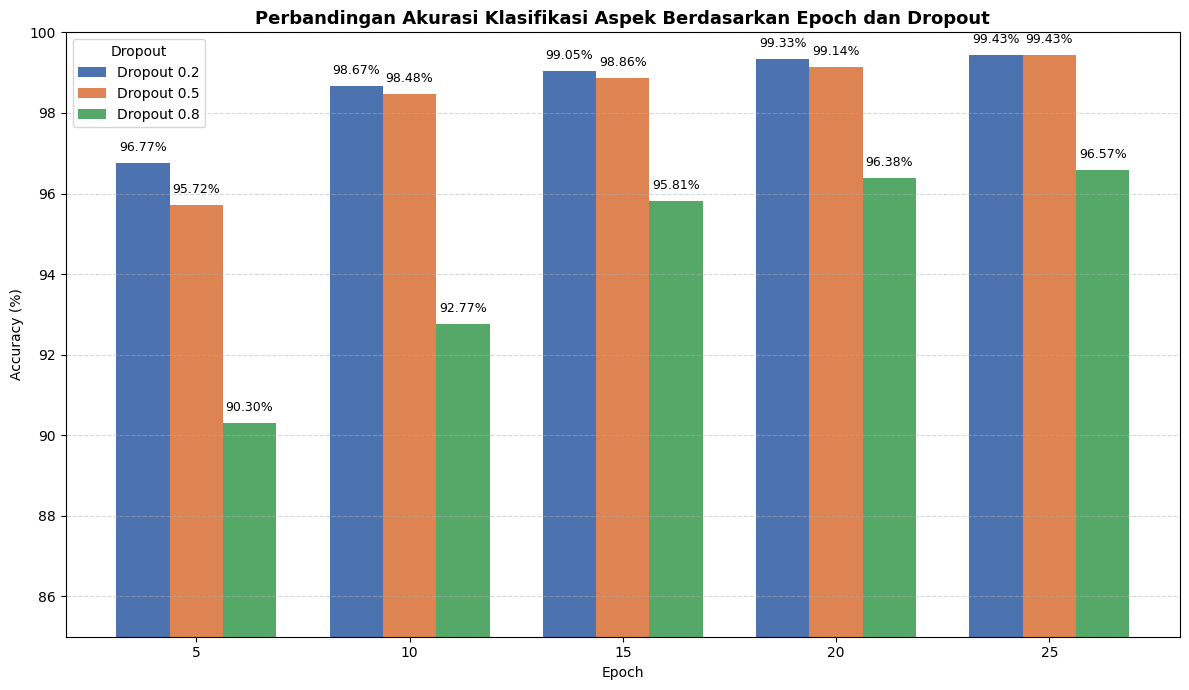

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# DATA AKURASI KLASIFIKASI ASPEK
# ==========================================================

epochs = [5, 10, 15, 20, 25]

accuracy = {
    0.2: [0.967650, 0.986679, 0.990485, 0.993340, 0.994291],
    0.5: [0.957184, 0.984776, 0.988582, 0.991437, 0.994291],
    0.8: [0.902950, 0.927688, 0.958135, 0.963844, 0.965747],
}

dropouts = [0.2, 0.5, 0.8]
colors = {0.2: "#4C72B0", 0.5: "#DD8452", 0.8: "#55A868"}

# ==========================================================
# GRAFIK BATANG AKURASI PER DROPOUT ACROSS EPOCH
# ==========================================================

x = np.arange(len(epochs))
width = 0.25

plt.figure(figsize=(12, 7))

for i, d in enumerate(dropouts):
    values = [v * 100 for v in accuracy[d]]
    bars = plt.bar(x + (i - 1) * width, values, width, label=f"Dropout {d}", color=colors[d])
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
                  f"{height:.2f}%", ha="center", fontsize=9)

plt.title("Perbandingan Akurasi Klasifikasi Aspek Berdasarkan Epoch dan Dropout",
          fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(x, epochs)
plt.ylim(85, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Dropout")
plt.tight_layout()
plt.show()

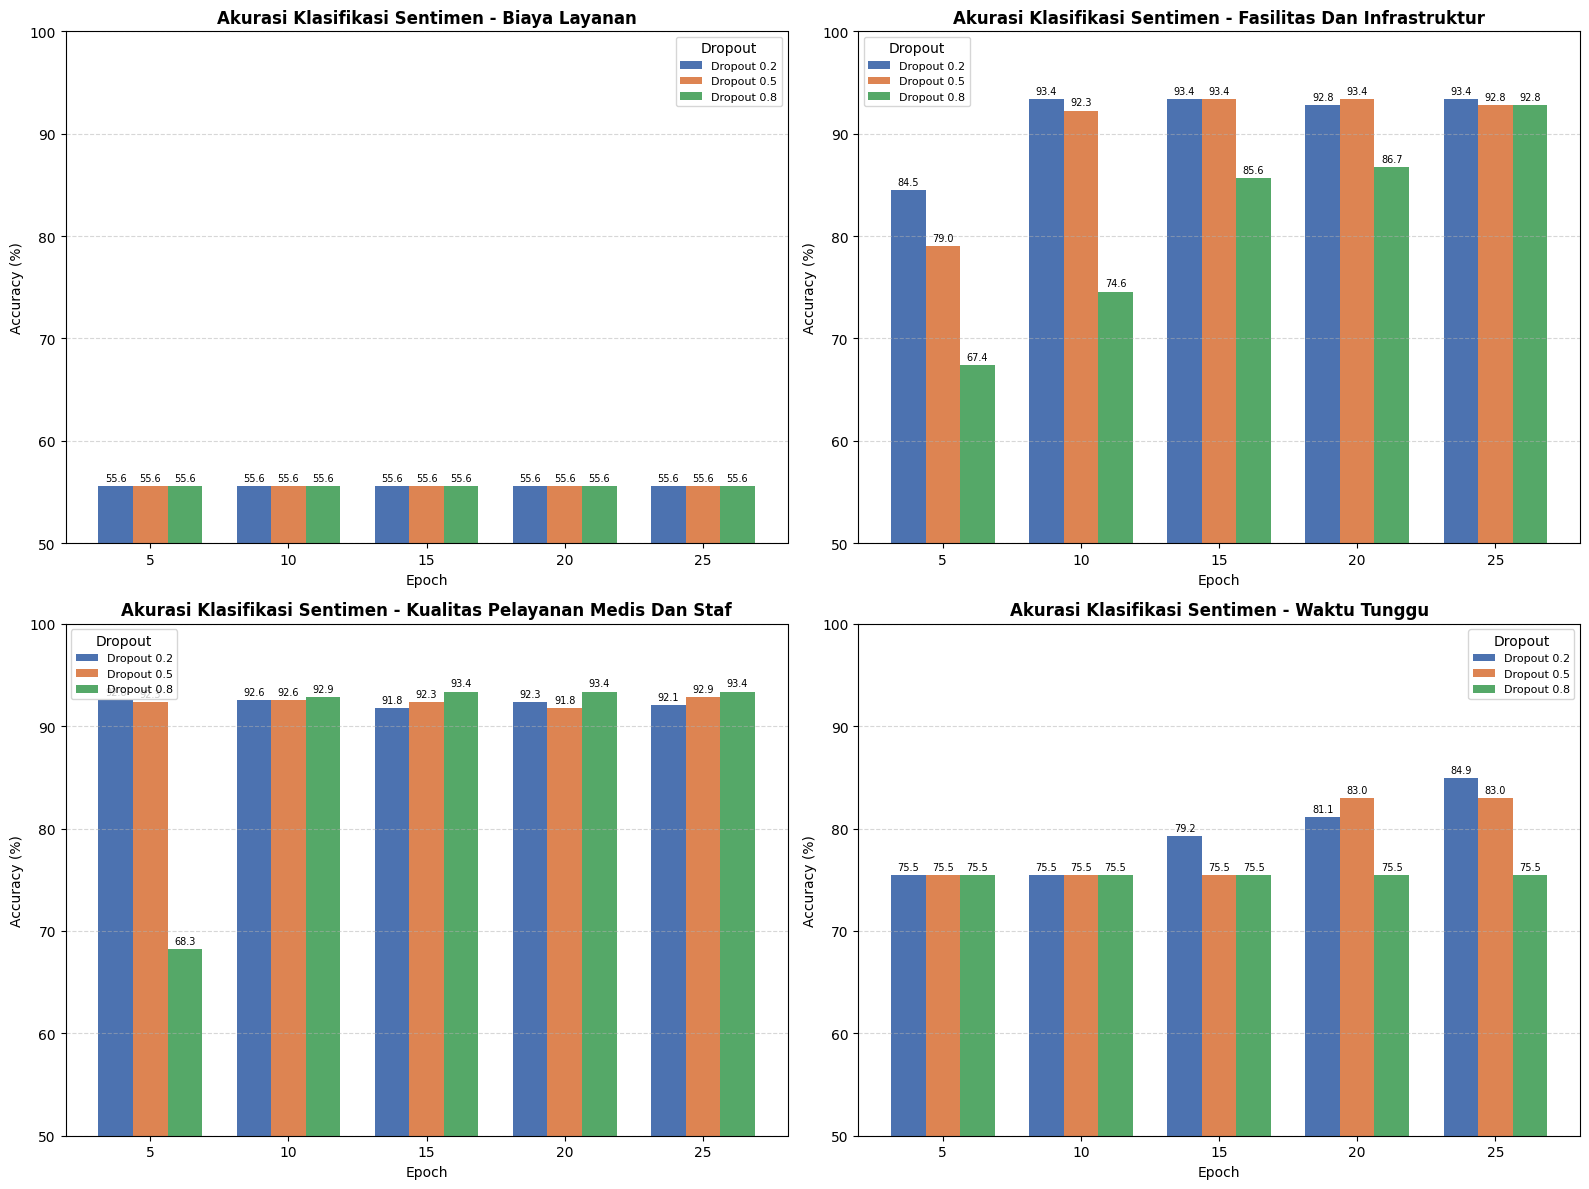

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# DATA AKURASI SENTIMEN PER ASPEK x DROPOUT x EPOCH
# (aspek "lainnya" tidak disertakan)
# ==========================================================

epochs = [5, 10, 15, 20, 25]
dropouts = [0.2, 0.5, 0.8]
colors = {0.2: "#4C72B0", 0.5: "#DD8452", 0.8: "#55A868"}

sentiment_accuracy = {
    "biaya layanan": {
        0.2: [0.555556, 0.555556, 0.555556, 0.555556, 0.555556],
        0.5: [0.555556, 0.555556, 0.555556, 0.555556, 0.555556],
        0.8: [0.555556, 0.555556, 0.555556, 0.555556, 0.555556],
    },
    "fasilitas dan infrastruktur": {
        0.2: [0.845304, 0.933702, 0.933702, 0.928177, 0.933702],
        0.5: [0.790055, 0.922652, 0.933702, 0.933702, 0.928177],
        0.8: [0.674033, 0.745856, 0.856354, 0.867403, 0.928177],
    },
    "kualitas pelayanan medis dan staf": {
        0.2: [0.925926, 0.925926, 0.917989, 0.923280, 0.920635],
        0.5: [0.923280, 0.925926, 0.923280, 0.917989, 0.928571],
        0.8: [0.682540, 0.928571, 0.933862, 0.933862, 0.933862],
    },
    "waktu tunggu": {
        0.2: [0.754717, 0.754717, 0.792453, 0.811321, 0.849057],
        0.5: [0.754717, 0.754717, 0.754717, 0.830189, 0.830189],
        0.8: [0.754717, 0.754717, 0.754717, 0.754717, 0.754717],
    },
}

# ==========================================================
# GRAFIK BATANG AKURASI SENTIMEN PER ASPEK
# ==========================================================

aspects = list(sentiment_accuracy.keys())
x = np.arange(len(epochs))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, aspek in zip(axes, aspects):
    data = sentiment_accuracy[aspek]

    for i, d in enumerate(dropouts):
        values = [v * 100 for v in data[d]]
        bars = ax.bar(x + (i - 1) * width, values, width, label=f"Dropout {d}", color=colors[d])
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                     f"{height:.1f}", ha="center", fontsize=7)

    ax.set_title(f"Akurasi Klasifikasi Sentimen - {aspek.title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(epochs)
    ax.set_ylim(50, 100)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Dropout", fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3121938947.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


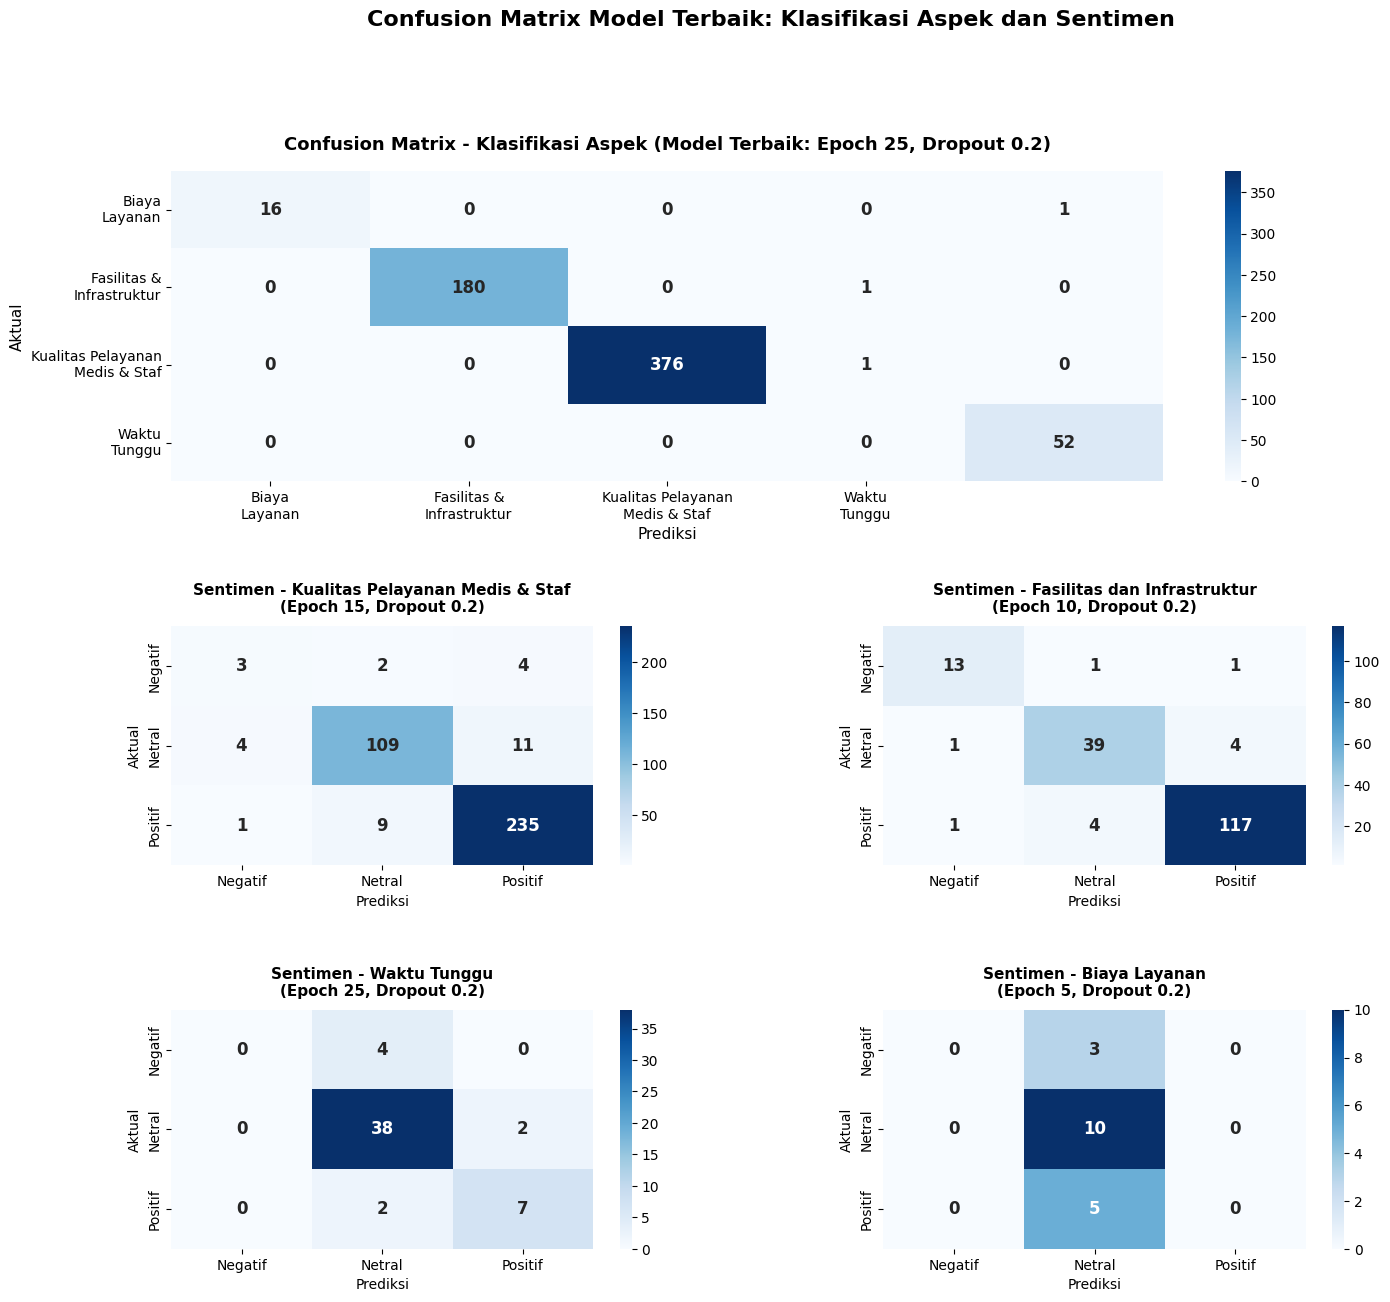

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ==========================================================
# DATA CONFUSION MATRIX
# ==========================================================

# Model terbaik klasifikasi ASPEK (epoch 25, dropout 0.2)
cm_aspek = np.array([
    [ 16,   0,   0,   0,   1],
    [  0, 180,   0,   1,   0],
    [  0,   0, 376,   1,   0],
    [  0,   0,   0,   0,  52],
])
label_aspek = [
    "Biaya\nLayanan",
    "Fasilitas &\nInfrastruktur",
    "Kualitas Pelayanan\nMedis & Staf",
    "Waktu\nTunggu",
]

# Model terbaik klasifikasi SENTIMEN per aspek
sentiment_matrices = {
    "Kualitas Pelayanan Medis & Staf\n(Epoch 15, Dropout 0.2)": np.array([
        [  3,   2,   4],
        [  4, 109,  11],
        [  1,   9, 235],
    ]),
    "Fasilitas dan Infrastruktur\n(Epoch 10, Dropout 0.2)": np.array([
        [ 13,   1,   1],
        [  1,  39,   4],
        [  1,   4, 117],
    ]),
    "Waktu Tunggu\n(Epoch 25, Dropout 0.2)": np.array([
        [ 0,  4,  0],
        [ 0, 38,  2],
        [ 0,  2,  7],
    ]),
    "Biaya Layanan\n(Epoch 5, Dropout 0.2)": np.array([
        [ 0,  3,  0],
        [ 0, 10,  0],
        [ 0,  5,  0],
    ]),
}

label_sentimen = ["Negatif", "Netral", "Positif"]

# ==========================================================
# LAYOUT FIGURE
# ==========================================================

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.3, 1, 1], hspace=0.55, wspace=0.35)

# --- Confusion Matrix Aspek (baris atas, full width) ---
ax_aspek = fig.add_subplot(gs[0, :])
sns.heatmap(
    cm_aspek,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_aspek,
    yticklabels=label_aspek,
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax_aspek,
)
ax_aspek.set_title("Confusion Matrix - Klasifikasi Aspek (Model Terbaik: Epoch 25, Dropout 0.2)",
                    fontsize=13, fontweight="bold", pad=15)
ax_aspek.set_xlabel("Prediksi", fontsize=11)
ax_aspek.set_ylabel("Aktual", fontsize=11)
ax_aspek.tick_params(axis="x", rotation=0)
ax_aspek.tick_params(axis="y", rotation=0)

# --- Confusion Matrix Sentimen per Aspek (2x2 grid) ---
positions = [gs[1, 0], gs[1, 1], gs[2, 0], gs[2, 1]]

for pos, (title, cm) in zip(positions, sentiment_matrices.items()):
    ax = fig.add_subplot(pos)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_sentimen,
        yticklabels=label_sentimen,
        cbar=True,
        annot_kws={"size": 12, "weight": "bold"},
        ax=ax,
    )
    ax.set_title(f"Sentimen - {title}", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Prediksi", fontsize=10)
    ax.set_ylabel("Aktual", fontsize=10)

fig.suptitle("Confusion Matrix Model Terbaik: Klasifikasi Aspek dan Sentimen",
             fontsize=16, fontweight="bold", y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

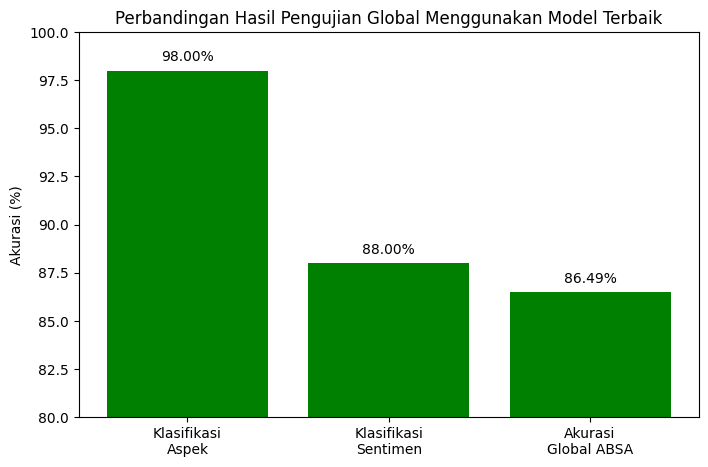

In [3]:
import matplotlib.pyplot as plt

# Data
kategori = ['Klasifikasi\nAspek',
             'Klasifikasi\nSentimen',
             'Akurasi\nGlobal ABSA']

akurasi = [98, 88, 86.49]

# Membuat grafik
plt.figure(figsize=(8,5))
bars = plt.bar(kategori, akurasi, color='green')

# Menampilkan nilai di atas batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        tinggi + 0.5,
        f'{tinggi:.2f}%',
        ha='center'
    )

plt.ylabel('Akurasi (%)')
plt.ylim(80, 100)
plt.title('Perbandingan Hasil Pengujian Global Menggunakan Model Terbaik')

plt.show()